In [127]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
import torchbnn as bnn
from tqdm.auto import tqdm


# Установка случайного сида для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [128]:
df = pd.read_csv('../data/data.csv')
df

,"Sigma, Mpa",T.K,t.h,Th,C,Cr,Co,Mo,W,Al,...,La,S,Si,Mn,P,Hf,Cu,Ge,Ga,Ni
0,241.316495,1144.2600,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.50,NaN,NaN,NaN,99.500
1,241.316495,1144.2600,113.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.75,NaN,NaN,NaN,99.250
2,241.316495,1144.2600,68.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.50,NaN,NaN,0.05,99.450
3,241.316495,1144.2600,40.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.50,NaN,NaN,0.20,99.300
4,241.316495,1144.2600,32.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.50,NaN,NaN,0.50,99.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3441,1061.792578,922.0389,1183.7,NaN,0.02,17.0,28.4,3.4,1.9,1.03,...,NaN,6.0,0.05,0.05,NaN,NaN,0.02,NaN,NaN,33.904
3442,1103.161120,866.4833,25554.7,NaN,0.02,17.0,28.4,3.4,1.9,1.03,...,NaN,6.0,0.05,0.05,NaN,NaN,0.02,NaN,NaN,33.904
3443,241.316495,1199.8170,183.2,NaN,0.18,10.0,15.0,3.0,NaN,5.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.750
3444,241.316495,1199.8170,153.0,NaN,0.18,10.0,15.0,3.0,NaN,5.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.750


In [129]:
mass = '232,03806	12,011	51,9961	58,933194	95,95	183,84	26,9815385	47,867	92,90637	10,81	55,845	88,90584	91,224	180,94788	186,207	101,07	50,9415	140,116	138,90547	32,06	28,085	54,938044	24,305	30,973761998	178,49	107,8682	63,546	208,9804	207,2	192,22	72,63	69,723	58,6934'.replace(',', '.').split()
element = 'Th	C	Cr	Co	Mo	W	Al	Ti	Nb	B	Fe	Y	Zr	Ta	Re	Ru	V	Ce	La	S	Si	Mn	Mg	P	Hf	Ag	Cu	Bi	Pb	Ir	Ge	Ga	Ni'.split()
atom_mass = dict(zip(element, mass))

In [130]:
atom_mass['Ni']

'58.6934'

In [131]:
for elem in df.drop(columns=['Sigma, Mpa', 'T.K', 't.h']).columns.to_list():
    df[elem] = df[elem] / float(atom_mass[elem])
df['sum'] = df[df.drop(columns=['Sigma, Mpa', 'T.K', 't.h']).columns.to_list()].sum(axis=1, skipna=True)
df['PLM'] = df['T.K'] * (20 + np.log10(df['t.h'])) * 1e-5

cols = df.drop(columns=['Sigma, Mpa', 'T.K', 't.h']).columns
df.loc[:, cols] = df.loc[:, cols].div(df['sum'], axis=0)
df.loc[:, cols] = df.loc[:, cols].div(df['Ni'], axis=0)



df = df.fillna(0)

df = df.drop(columns=['T.K', 't.h', 'Ni', 'sum'])

df

,"Sigma, Mpa",Th,C,Cr,Co,Mo,W,Al,Ti,Nb,...,La,S,Si,Mn,P,Hf,Cu,Ge,Ga,PLM
0,241.316495,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.001652,0.000000,0.0,0.000000,0.139405
1,241.316495,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.002485,0.000000,0.0,0.000000,0.149239
2,241.316495,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.001653,0.000000,0.0,0.000423,0.147465
3,241.316495,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.001656,0.000000,0.0,0.001695,0.146154
4,241.316495,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.001661,0.000000,0.0,0.004252,0.145925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3441,1061.792578,0.0,0.002883,0.566000,0.834251,0.061344,0.017892,0.066086,0.112115,0.020497,...,0.0,0.323986,0.003082,0.001576,0.0,0.000000,0.000545,0.0,0.000000,0.368295
3442,1103.161120,0.0,0.002883,0.566000,0.834251,0.061344,0.017892,0.066086,0.112115,0.020497,...,0.0,0.323986,0.003082,0.001576,0.0,0.000000,0.000545,0.0,0.000000,0.366118
3443,241.316495,0.0,0.014721,0.188921,0.250025,0.030713,0.000000,0.200238,0.112870,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.262391
3444,241.316495,0.0,0.014721,0.188921,0.250025,0.030713,0.000000,0.200238,0.112870,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.261469


In [132]:
def y_from_sigma(sigma_mpa):
    # y = -log10(sigma)
    return -np.log10(sigma_mpa)

def sigma_from_y(y):
    # sigma = 10^(-y)
    return 10 ** (-y)

def calculate_mse(y_pred, y_true):
    """Вычисление MSE (Mean Squared Error)"""
    return torch.mean((y_pred - y_true) ** 2).item()

def calculate_rmse_absolute(sigma_pred, sigma_real):
    """
    Вычисление RMSE для физических значений σ (MPa)
    Корень из среднего квадрата абсолютных ошибок
    """
    mse = torch.mean((sigma_pred - sigma_real) ** 2).item()
    return np.sqrt(mse)

def calculate_rmse_relative(sigma_pred, sigma_real):
    """
    Вычисление RMSE согласно формуле (6) из статьи.
    Это относительная ошибка (Root Mean Square Relative Error)
    """
    epsilon = 1e-8
    relative_error = (sigma_pred - sigma_real) / (sigma_real.abs() + epsilon)
    mse_relative = torch.mean(relative_error ** 2).item()
    return np.sqrt(mse_relative)

In [133]:
target_col = 'Sigma, Mpa'
sigma = np.asarray(df[target_col], dtype=np.float32).reshape(-1, 1)
y = np.asarray(y_from_sigma(sigma), dtype=np.float32).reshape(-1, 1).astype("float32")
X = df.copy().drop(columns=[target_col]).to_numpy().astype("float32")
sigma, sigma_from_y(y)

(array([[241.3165 ],
        [241.3165 ],
        [241.3165 ],
        ...,
        [241.3165 ],
        [241.3165 ],
        [275.79028]], shape=(3446, 1), dtype=float32),
 array([[241.3166],
        [241.3166],
        [241.3166],
        ...,
        [241.3166],
        [241.3166],
        [275.7904]], shape=(3446, 1), dtype=float32))

In [134]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    shuffle=True
)


In [135]:
class AlloyNet(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(AlloyNet, self).__init__()
        self.hidden = nn.Linear(input_size, hidden_size)
        self.activation = nn.Tanh()
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.hidden(x)
        x = self.activation(x)
        x = self.output(x)
        return x

In [136]:
def train_single_network(X_train, y_train, X_val, y_val, input_size, hidden_size = 13, max_iterations=10, epochs_per_iteration=10):
    """
    Обучение одной сети с проверкой критерия остановки.
    Критерий: MSE_val >= 1.9 * MSE_train
    """
    model = AlloyNet(input_size, hidden_size)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    
    best_model_state = None
    stopped = False

    # Преобразуем данные в тензоры PyTorch
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train).view(-1, 1)
    X_val_t = torch.FloatTensor(X_val)
    y_val_t = torch.FloatTensor(y_val).view(-1, 1)

    print("  Начало обучения сети...")

    # Внешний цикл: Итерации (до 10)
    # В тексте: "The training procedure consists of seven cycles... with a certain number of iterations (up to 10)"
    for iteration in range(max_iterations):
        if stopped:
            break
            
        # Внутренний цикл: Эпохи (до 10)
        # В тексте: "Each iteration consists of several (up to 10) training epochs"
        for epoch in range(epochs_per_iteration):
            model.train()
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(X_train_t)
            loss = criterion(outputs, y_train_t)
            
            # Backward pass
            loss.backward()
            optimizer.step()
        
        # Проверка критерия остановки после итерации (блока эпох)
        model.eval()
        with torch.no_grad():
            train_pred = model(X_train_t)
            val_pred = model(X_val_t)
            
            mse_train = calculate_mse(train_pred, y_train_t)
            mse_val = calculate_mse(val_pred, y_val_t)
            
            # Критерий из текста: MSE.validation >= 1.9 * MSE.training
            # Это сигнал о начале переобучения (divergence)
            if mse_val >= 1.9 * mse_train:
                print(f"    Критерий остановки достигнут на итерации {iteration+1}: "
                      f"MSE_val ({mse_val:.4f}) >= 1.9 * MSE_train ({1.9*mse_train:.4f})")
                stopped = True
                # Сохраняем веса текущего состояния (или можно предыдущего, но текст говорит "stop criterion... is the desired level")
                best_model_state = model.state_dict()
                break
            else:
                # Если критерий еще не достигнут, продолжаем тренировку.
                # В реальной задаче здесь можно сохранять best_model_state по минимальной MSE_val
                best_model_state = model.state_dict() 

    # Загружаем лучшие веса
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        
    return model

In [137]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_temp).astype("float32")
y_scaled = scaler_y.fit_transform(y_temp).astype("float32").reshape(-1,1)

X_test_scaled = scaler_X.transform(X_test).astype("float32")
# y_test_scaled = scaler_y.transform(y_test).astype("float32").reshape(-1,1)

# 2. Ансамбль из 7 сетей (BRANN / Bootstrap procedure)
# Текст: "The modeling ensemble consists of seven networks that act in parallel."
n_ensemble = 7
models = []



for i in range(n_ensemble):
    print(f"\nОбучение сети #{i+1}:")
    
    # Случайное разбиение на Training (75%) и Validation (25%)
    # Текст: "At each iteration, the formed dataset was randomly divided into training (75%) and validation (25%)"
    X_train, X_val, y_train, y_val = train_test_split(
        X_scaled, y_scaled, test_size=0.25, random_state=i
    )
    
    # Обучение одной сети
    model = train_single_network(
        X_train, y_train, X_val, y_val
        ,input_size=27
        ,hidden_size=13
        ,max_iterations=10
        ,epochs_per_iteration=100
    )
    models.append(model)



Обучение сети #1:
  Начало обучения сети...

Обучение сети #2:
  Начало обучения сети...

Обучение сети #3:
  Начало обучения сети...

Обучение сети #4:
  Начало обучения сети...

Обучение сети #5:
  Начало обучения сети...

Обучение сети #6:
  Начало обучения сети...

Обучение сети #7:
  Начало обучения сети...


In [139]:

X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test).view(-1, 1)

predictions_list = []

with torch.no_grad():
    for model in models:
        model.eval()
        pred = model(X_test_t)
        predictions_list.append(pred)

# Усреднение предсказаний 7 сетей
stacked_preds = torch.stack(predictions_list)
y_pred_scaled = torch.mean(stacked_preds, dim=0)

# Обратная нормализация y
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# Обратная логарифмическая трансформация (формула 4)
sigma_pred = sigma_from_y(y_pred)
sigma_pred_tensor = torch.FloatTensor(sigma_pred).view(-1, 1)
sigma_real_tensor = torch.FloatTensor(sigma_from_y(y_test_t)).view(-1, 1)

# Расчет ошибок
rmse_absolute = calculate_rmse_absolute(sigma_pred_tensor, sigma_real_tensor)
rmse_relative = calculate_rmse_relative(sigma_pred_tensor, sigma_real_tensor)

# MAPE (Mean Absolute Percentage Error)
mape = torch.mean(torch.abs((sigma_pred_tensor - sigma_real_tensor) / 
                                (sigma_real_tensor + 1e-8))) * 100


# print(f"""{y_pred_scaled[:5]=},\n {y_pred[:5]=},\n
# {sigma_pred[:5]=}, \n{sigma_real_tensor[:5]=} \n{y_test_t[:5]=}\n""")
print(f"\nРезультаты:")
print(f"  RMSE (абсолютная): {rmse_absolute:.2f} MPa")
print(f"  RMSE (относительная, формула 6): {rmse_relative:.4f}")
print(f"  MAPE: {mape.item():.2f}%")
print(f"  Мин. предсказанное σ: {sigma_pred.min():.2f} MPa")
print(f"  Макс. предсказанное σ: {sigma_pred.max():.2f} MPa")
print(f"  Мин. реальный σ: {sigma_real_tensor.min():.2f} MPa")
print(f"  Макс. реальный σ: {sigma_real_tensor.max():.2f} MPa")


Результаты:
  RMSE (абсолютная): 129.46 MPa
  RMSE (относительная, формула 6): 0.8007
  MAPE: 33.68%
  Мин. предсказанное σ: 29.53 MPa
  Макс. предсказанное σ: 1453.36 MPa
  Мин. реальный σ: 10.00 MPa
  Макс. реальный σ: 1279.00 MPa


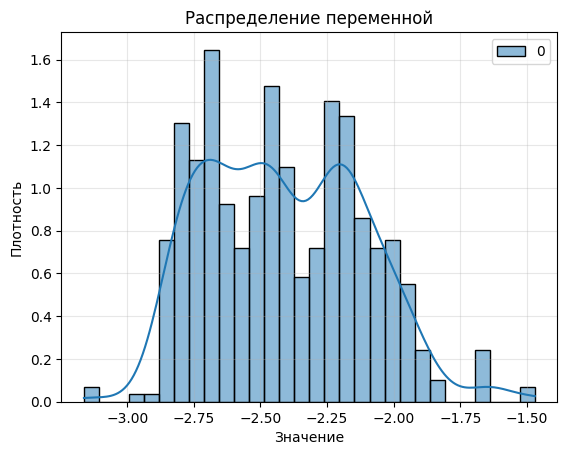

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.histplot(y_pred, kde=True, bins=30, color='steelblue', stat='density')
plt.title('Распределение переменной')
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.grid(True, alpha=0.3)
plt.show()

In [145]:
eps = torch.tensor(100.0)  # например, 50 MPa

relative_rmse_safe = torch.sqrt(
    torch.mean(((sigma_pred_tensor - sigma_real_tensor) / torch.maximum(sigma_real_tensor, eps)) ** 2)
)

mape_safe = torch.mean(
    torch.abs((sigma_pred_tensor - sigma_real_tensor) / torch.maximum(sigma_real_tensor, eps))
) * 100

print(f"Safe relative RMSE: {relative_rmse_safe:.4f}")
print(f"Safe MAPE         : {mape_safe:.2f}%")

Safe relative RMSE: 0.4997
Safe MAPE         : 28.06%
